In [11]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.lines import Line2D


# ============================================================
# Project root
# ============================================================

cwd = Path.cwd().resolve()

project_root = None

for candidate in [cwd, *cwd.parents]:
    if (candidate / "results" / "brt").exists():
        project_root = candidate
        break

if project_root is None:
    raise RuntimeError(
        "Project root not found. "
        "Expected a results/brt directory."
    )


# ============================================================
# Load metric results
# ============================================================

paths = {
    "euclidean": project_root / "results" / "brt" / "euclidean.npz",
    "dce": project_root / "results" / "brt" / "dce1s.npz",
    "ttc": project_root / "results" / "brt" / "ttc.npz",
}

for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(
            f"{name}: file not found:\n{path}"
        )

euclidean = np.load(paths["euclidean"], allow_pickle=False)
dce = np.load(paths["dce"], allow_pickle=False)
ttc = np.load(paths["ttc"], allow_pickle=False)


# ============================================================
# Value functions
# ============================================================

V_euclidean = euclidean["BRT"]
V_dce = dce["BRT"]
V_ttc = ttc["BRT"]


# ============================================================
# Coordinates
# State order:
# x_rel, y_rel, theta_rel, v_H, delta_E, v_E
# ============================================================

coordinate_names = [
    "x_rel",
    "y_rel",
    "theta_rel",
    "v_H",
    "delta_E",
    "v_E",
]

for name in coordinate_names:

    reference = euclidean[name]

    if not np.allclose(reference, dce[name]):
        raise ValueError(
            f"Euclidean and DCE have different '{name}' grids."
        )

    if not np.allclose(reference, ttc[name]):
        raise ValueError(
            f"Euclidean and TTC have different '{name}' grids."
        )


x_rel = euclidean["x_rel"]
y_rel = euclidean["y_rel"]
theta_rel = euclidean["theta_rel"]
v_H = euclidean["v_H"]
delta_E = euclidean["delta_E"]
v_E = euclidean["v_E"]


if not (
    V_euclidean.shape
    == V_dce.shape
    == V_ttc.shape
):
    raise ValueError(
        "The three BRT arrays do not have the same shape."
    )


# ============================================================
# TTC metadata
# ============================================================

ttc_metadata = json.loads(
    ttc["metadata_json"].item()
)

ttc_horizon = (
    ttc_metadata["metric"]["parameters"]["horizon"]
)

ttc_no_collision = 2.0 * ttc_horizon


# ============================================================
# Information
# ============================================================

print("Project root:")
print(project_root)

print("\nBRT shape:")
print(V_euclidean.shape)

print("\nVelocity grid:")
print(v_E)

print("\nTheta grid [deg]:")
print(np.rad2deg(theta_rel))

print("\nDelta grid [deg]:")
print(np.rad2deg(delta_E))

print(
    f"\nTTC horizon: {ttc_horizon:.2f} s"
)

print(
    f"TTC no-collision value: "
    f"{ttc_no_collision:.2f} s"
)


Project root:
/home/alessio-grisorio/TESI/hj_reachability

BRT shape:
(26, 13, 15, 8, 21, 8)

Velocity grid:
[ 1.         2.4285715  3.857143   5.2857146  6.714286   8.142858
  9.571429  11.       ]

Theta grid [deg]:
[-4.5000000e+01 -3.8571426e+01 -3.2142857e+01 -2.5714285e+01
 -1.9285715e+01 -1.2857142e+01 -6.4285684e+00  1.0672170e-06
  6.4285736e+00  1.2857146e+01  1.9285715e+01  2.5714289e+01
  3.2142860e+01  3.8571430e+01  4.5000000e+01]

Delta grid [deg]:
[-15.        -13.5       -12.        -10.5        -9.         -7.5
  -6.         -4.5        -3.         -1.499999    0.          1.5
   3.0000002   4.5000005   6.          7.5         9.         10.5
  12.000001   13.5        15.       ]

TTC horizon: 3.00 s
TTC no-collision value: 6.00 s


In [12]:
# ============================================================
# Requested conditions
# ============================================================

V_SLOW_TARGET = 4.0
V_FAST_TARGET = 8.0

THETA_0_TARGET = 0.0
THETA_10_TARGET = np.deg2rad(10.0)

DELTA_TARGET = 0.0


def nearest_index(vector, target):
    return int(
        np.argmin(
            np.abs(vector - target)
        )
    )


# ------------------------------------------------------------
# Indices
# ------------------------------------------------------------

i_theta_0 = nearest_index(
    theta_rel,
    THETA_0_TARGET,
)

i_theta_10 = nearest_index(
    theta_rel,
    THETA_10_TARGET,
)

i_delta_0 = nearest_index(
    delta_E,
    DELTA_TARGET,
)

i_vH_slow = nearest_index(
    v_H,
    V_SLOW_TARGET,
)

i_vH_fast = nearest_index(
    v_H,
    V_FAST_TARGET,
)

i_vE_slow = nearest_index(
    v_E,
    V_SLOW_TARGET,
)

i_vE_fast = nearest_index(
    v_E,
    V_FAST_TARGET,
)


# ------------------------------------------------------------
# Actual grid values
# ------------------------------------------------------------

theta_0_value = theta_rel[i_theta_0]
theta_10_value = theta_rel[i_theta_10]
delta_0_value = delta_E[i_delta_0]

vH_slow = v_H[i_vH_slow]
vH_fast = v_H[i_vH_fast]

vE_slow = v_E[i_vE_slow]
vE_fast = v_E[i_vE_fast]


print("ACTUAL GRID VALUES")
print("------------------")

print(
    f"theta ~ 0 deg  -> "
    f"{np.rad2deg(theta_0_value):.3f} deg"
)

print(
    f"theta ~ 10 deg -> "
    f"{np.rad2deg(theta_10_value):.3f} deg"
)

print(
    f"delta_E        -> "
    f"{np.rad2deg(delta_0_value):.3f} deg"
)

print(
    f"slow v_H       -> "
    f"{vH_slow:.3f} m/s"
)

print(
    f"fast v_H       -> "
    f"{vH_fast:.3f} m/s"
)

print(
    f"slow v_E       -> "
    f"{vE_slow:.3f} m/s"
)

print(
    f"fast v_E       -> "
    f"{vE_fast:.3f} m/s"
)


# ============================================================
# Common color scales
#
# Euclidean + DCE:
# one common scale in meters
#
# TTC:
# one separate scale in seconds
# ============================================================

meter_vmin = float(
    min(
        np.nanmin(V_euclidean),
        np.nanmin(V_dce),
    )
)

meter_vmax = float(
    max(
        np.nanmax(V_euclidean),
        np.nanmax(V_dce),
    )
)

ttc_vmin = float(
    np.nanmin(V_ttc)
)

ttc_vmax = float(
    np.nanmax(V_ttc)
)


def make_norm(vmin, vmax):
    if vmin < 0.0 < vmax:
        return TwoSlopeNorm(
            vmin=vmin,
            vcenter=0.0,
            vmax=vmax,
        )

    return Normalize(
        vmin=vmin,
        vmax=vmax,
    )


meter_norm = make_norm(
    meter_vmin,
    meter_vmax,
)

ttc_norm = make_norm(
    ttc_vmin,
    ttc_vmax,
)

meter_levels = np.linspace(
    meter_vmin,
    meter_vmax,
    50,
)

ttc_levels = np.linspace(
    ttc_vmin,
    ttc_vmax,
    50,
)


# ============================================================
# Slice extraction
# ============================================================

def get_xy_slice(
    V,
    *,
    theta_index,
    vH_index,
    delta_index,
    vE_index,
):
    return V[
        :,
        :,
        theta_index,
        vH_index,
        delta_index,
        vE_index,
    ]


# ============================================================
# 3D comparison
# ============================================================

def plot_3d_comparison(
    *,
    vH_index,
    vE_index,
    condition_name,
):
    V_e = V_euclidean[
        :, :, :, vH_index, i_delta_0, vE_index
    ]

    V_d = V_dce[
        :, :, :, vH_index, i_delta_0, vE_index
    ]

    V_t = V_ttc[
        :, :, :, vH_index, i_delta_0, vE_index
    ]

    theta_deg = np.rad2deg(theta_rel)

    X, Y, THETA = np.meshgrid(
        x_rel,
        y_rel,
        theta_deg,
        indexing="ij",
    )

    fig = plt.figure(
        figsize=(18, 6.3),
        constrained_layout=True,
    )

    axes = [
        fig.add_subplot(1, 3, 1, projection="3d"),
        fig.add_subplot(1, 3, 2, projection="3d"),
        fig.add_subplot(1, 3, 3, projection="3d"),
    ]

    sc_e = axes[0].scatter(
        X.ravel(),
        Y.ravel(),
        THETA.ravel(),
        c=V_e.ravel(),
        cmap="coolwarm",
        norm=meter_norm,
        s=9,
        alpha=0.85,
        depthshade=False,
    )

    axes[1].scatter(
        X.ravel(),
        Y.ravel(),
        THETA.ravel(),
        c=V_d.ravel(),
        cmap="coolwarm",
        norm=meter_norm,
        s=9,
        alpha=0.85,
        depthshade=False,
    )

    sc_t = axes[2].scatter(
        X.ravel(),
        Y.ravel(),
        THETA.ravel(),
        c=V_t.ravel(),
        cmap="coolwarm",
        norm=ttc_norm,
        s=9,
        alpha=0.85,
        depthshade=False,
    )

    titles = [
        "Euclidean",
        "DCE",
        "TTC",
    ]

    for ax, title in zip(
        axes,
        titles,
    ):
        ax.set_title(
            title,
            fontsize=13,
        )

        ax.set_xlabel(
            r"$x_{\mathrm{rel}}$ [m]"
        )

        ax.set_ylabel(
            r"$y_{\mathrm{rel}}$ [m]"
        )

        ax.set_zlabel(
            r"$\theta_{\mathrm{rel}}$ [deg]"
        )

        ax.set_xlim(
            x_rel.min(),
            x_rel.max(),
        )

        ax.set_ylim(
            y_rel.min(),
            y_rel.max(),
        )

        ax.set_zlim(
            theta_deg.min(),
            theta_deg.max(),
        )

        ax.view_init(
            elev=24,
            azim=-58,
        )

        ax.set_box_aspect(
            (1.5, 1.0, 0.9)
        )

    fig.colorbar(
        sc_e,
        ax=axes[:2],
        shrink=0.72,
        pad=0.03,
        label=r"$V(-3\,\mathrm{s})$ [m]",
    )

    fig.colorbar(
        sc_t,
        ax=axes[2],
        shrink=0.72,
        pad=0.03,
        label=r"$V(-3\,\mathrm{s})$ TTC [s]",
    )

    fig.suptitle(
        (
            f"{condition_name}\n"
            rf"$v_E={v_E[vE_index]:.2f}$ m/s, "
            rf"$v_H={v_H[vH_index]:.2f}$ m/s, "
            rf"$\delta_E="
            f"{np.rad2deg(delta_0_value):.2f}"
            r"^\circ$"
        ),
        fontsize=15,
    )

    plt.show()


# ============================================================
# 2D XY comparison
# ============================================================

def plot_xy_comparison(
    *,
    theta_index,
    vH_index,
    vE_index,
    condition_name,
):
    V_e = get_xy_slice(
        V_euclidean,
        theta_index=theta_index,
        vH_index=vH_index,
        delta_index=i_delta_0,
        vE_index=vE_index,
    )

    V_d = get_xy_slice(
        V_dce,
        theta_index=theta_index,
        vH_index=vH_index,
        delta_index=i_delta_0,
        vE_index=vE_index,
    )

    V_t = get_xy_slice(
        V_ttc,
        theta_index=theta_index,
        vH_index=vH_index,
        delta_index=i_delta_0,
        vE_index=vE_index,
    )

    X, Y = np.meshgrid(
        x_rel,
        y_rel,
        indexing="ij",
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5.5),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    cf_e = axes[0].contourf(
        X,
        Y,
        V_e,
        levels=meter_levels,
        cmap="coolwarm",
        norm=meter_norm,
        extend="both",
    )

    axes[1].contourf(
        X,
        Y,
        V_d,
        levels=meter_levels,
        cmap="coolwarm",
        norm=meter_norm,
        extend="both",
    )

    cf_t = axes[2].contourf(
        X,
        Y,
        V_t,
        levels=ttc_levels,
        cmap="coolwarm",
        norm=ttc_norm,
        extend="both",
    )

    # Zero level
    for ax, Z in zip(
        axes,
        [V_e, V_d, V_t],
    ):
        ax.contour(
            X,
            Y,
            Z,
            levels=[0.0],
            colors="black",
            linewidths=2.0,
        )

    titles = [
        "Euclidean",
        "DCE",
        "TTC",
    ]

    for ax, title in zip(
        axes,
        titles,
    ):
        ax.set_title(
            title,
            fontsize=13,
        )

        ax.set_xlabel(
            r"$x_{\mathrm{rel}}$ [m]"
        )

        ax.set_xlim(
            x_rel.min(),
            x_rel.max(),
        )

        ax.set_ylim(
            y_rel.min(),
            y_rel.max(),
        )

        ax.set_aspect(
            "equal",
            adjustable="box",
        )

        ax.grid(
            alpha=0.2,
            linestyle="--",
        )

    axes[0].set_ylabel(
        r"$y_{\mathrm{rel}}$ [m]"
    )

    fig.colorbar(
        cf_e,
        ax=axes[:2],
        shrink=0.88,
        pad=0.025,
        label=r"$V(-3\,\mathrm{s})$ [m]",
    )

    fig.colorbar(
        cf_t,
        ax=axes[2],
        shrink=0.88,
        pad=0.025,
        label=r"$V(-3\,\mathrm{s})$ TTC [s]",
    )

    theta_deg = np.rad2deg(
        theta_rel[theta_index]
    )

    fig.suptitle(
        (
            f"{condition_name}\n"
            rf"$v_E={v_E[vE_index]:.2f}$ m/s, "
            rf"$v_H={v_H[vH_index]:.2f}$ m/s, "
            rf"$\theta_{{rel}}={theta_deg:.2f}^\circ$, "
            rf"$\delta_E="
            f"{np.rad2deg(delta_0_value):.2f}"
            r"^\circ$"
        ),
        fontsize=15,
    )

    plt.show()


ACTUAL GRID VALUES
------------------
theta ~ 0 deg  -> 0.000 deg
theta ~ 10 deg -> 12.857 deg
delta_E        -> 0.000 deg
slow v_H       -> 3.857 m/s
fast v_H       -> 8.143 m/s
slow v_E       -> 3.857 m/s
fast v_E       -> 8.143 m/s


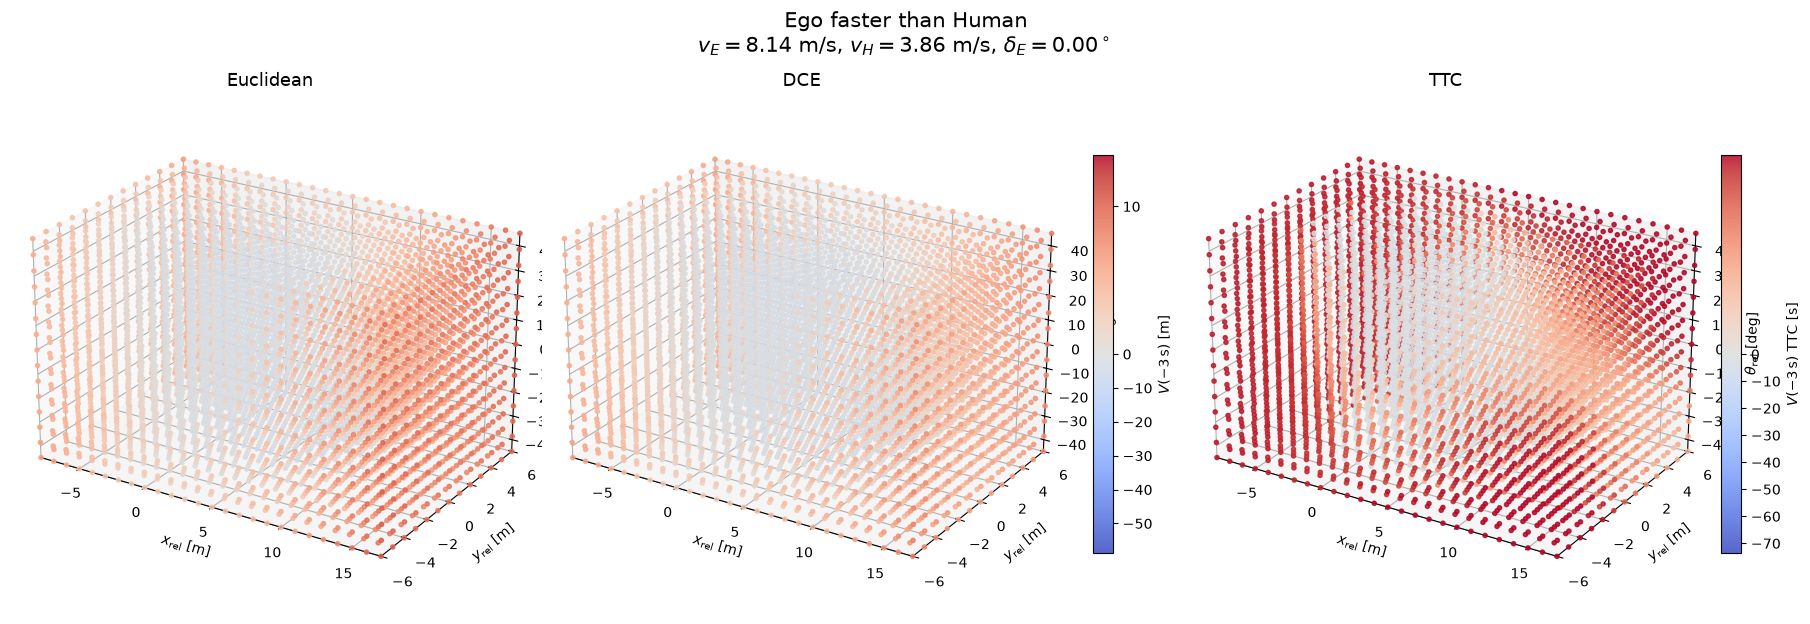

In [13]:
plot_3d_comparison(
    vH_index=i_vH_slow,
    vE_index=i_vE_fast,
    condition_name="Ego faster than Human",
)


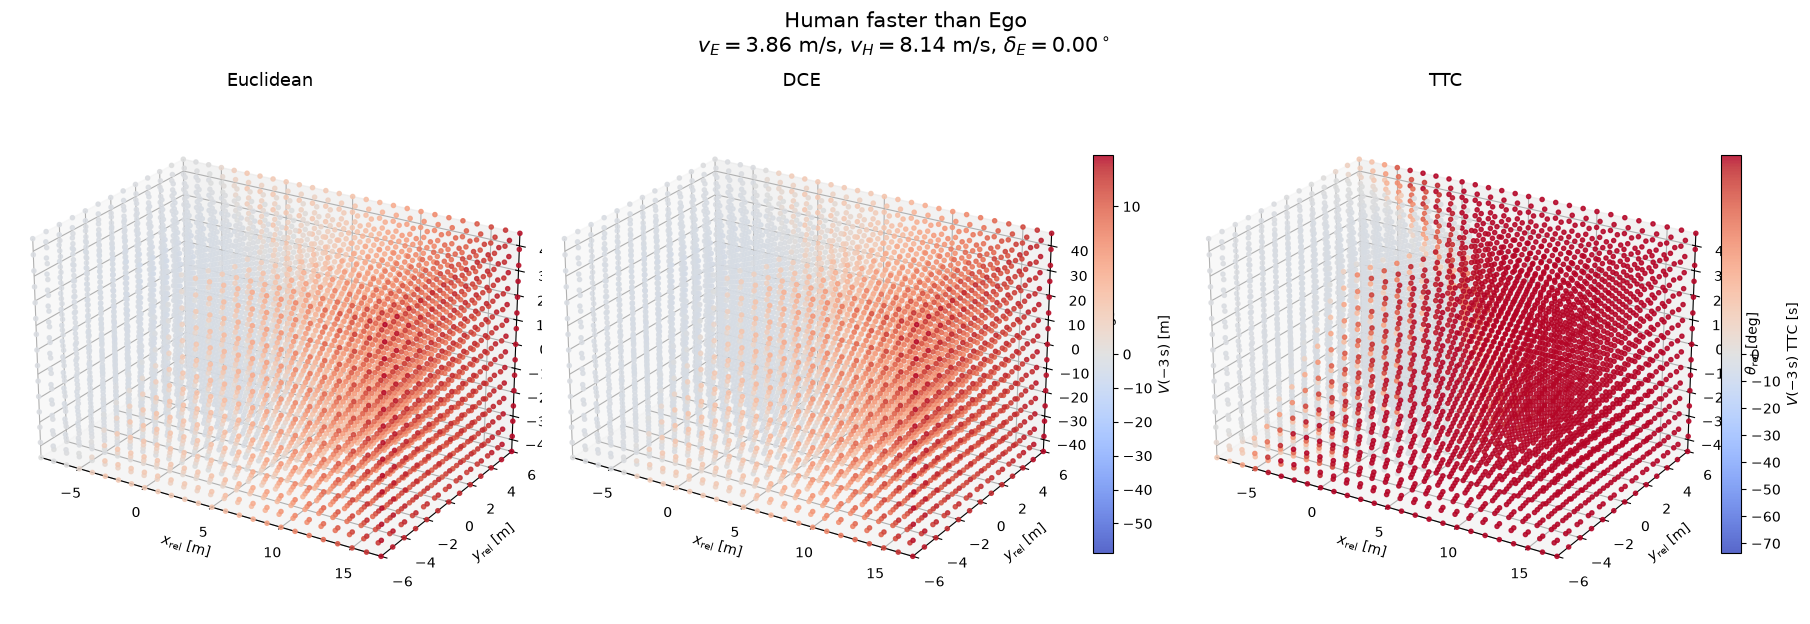

In [14]:
plot_3d_comparison(
    vH_index=i_vH_fast,
    vE_index=i_vE_slow,
    condition_name="Human faster than Ego",
)


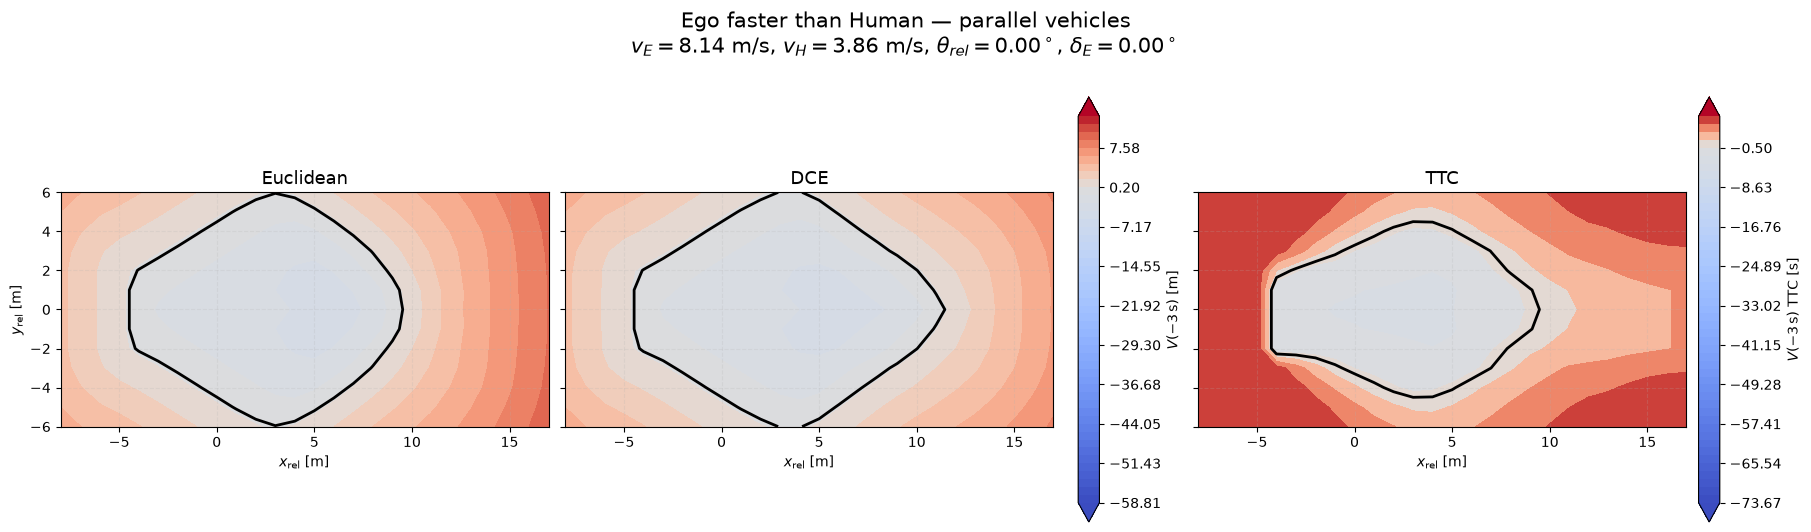

In [15]:
plot_xy_comparison(
    theta_index=i_theta_0,
    vH_index=i_vH_slow,
    vE_index=i_vE_fast,
    condition_name=(
        "Ego faster than Human — parallel vehicles"
    ),
)


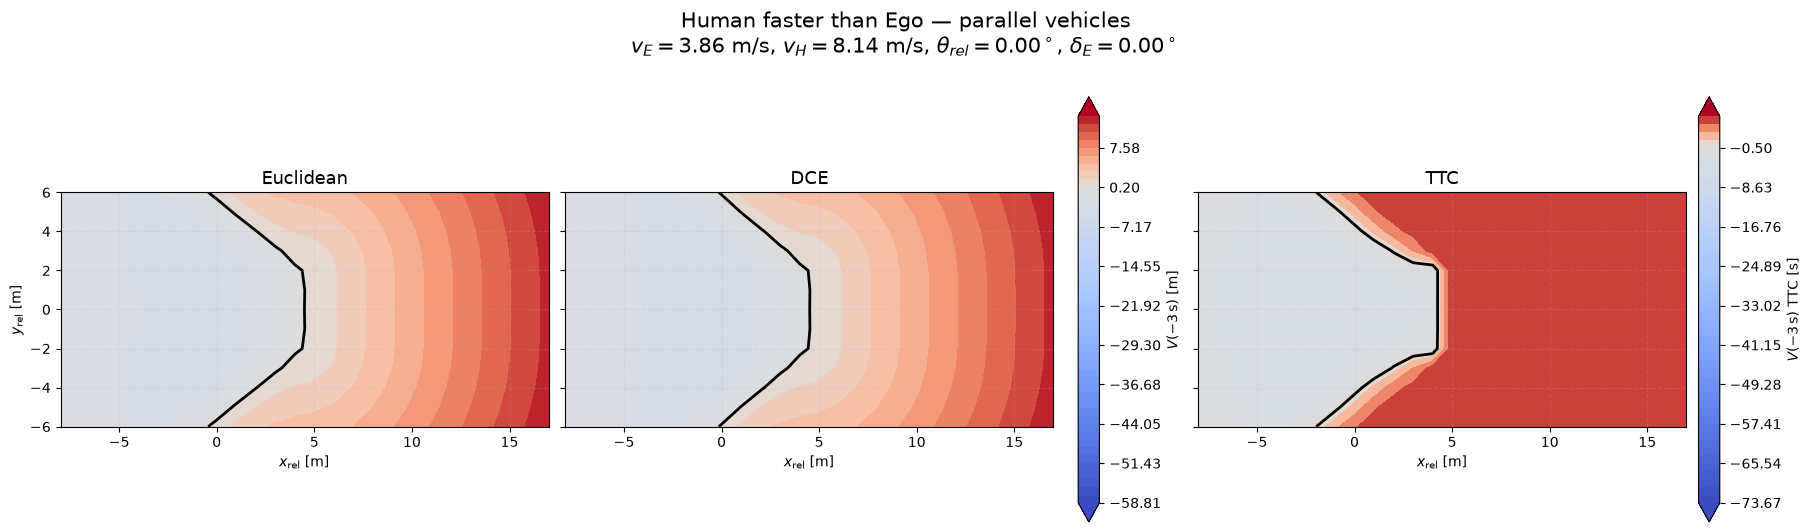

In [16]:
plot_xy_comparison(
    theta_index=i_theta_0,
    vH_index=i_vH_fast,
    vE_index=i_vE_slow,
    condition_name=(
        "Human faster than Ego — parallel vehicles"
    ),
)


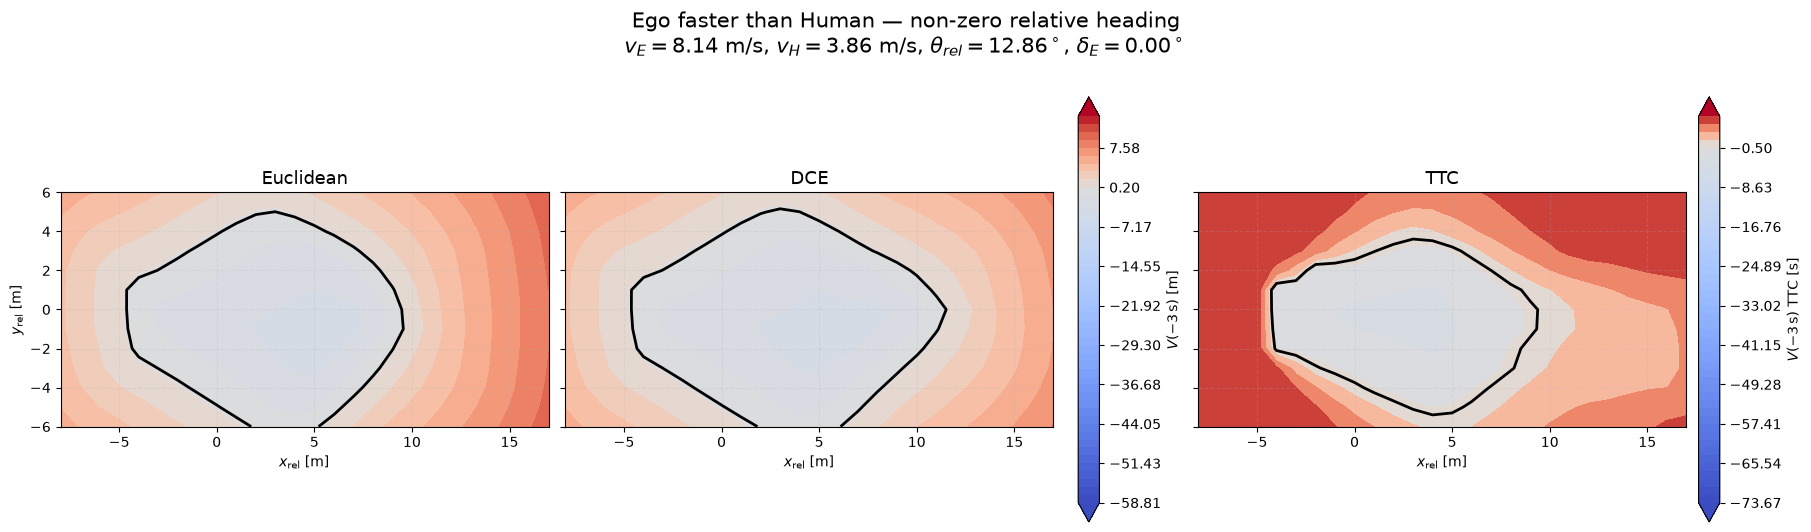

In [17]:
plot_xy_comparison(
    theta_index=i_theta_10,
    vH_index=i_vH_slow,
    vE_index=i_vE_fast,
    condition_name=(
        "Ego faster than Human — non-zero relative heading"
    ),
)


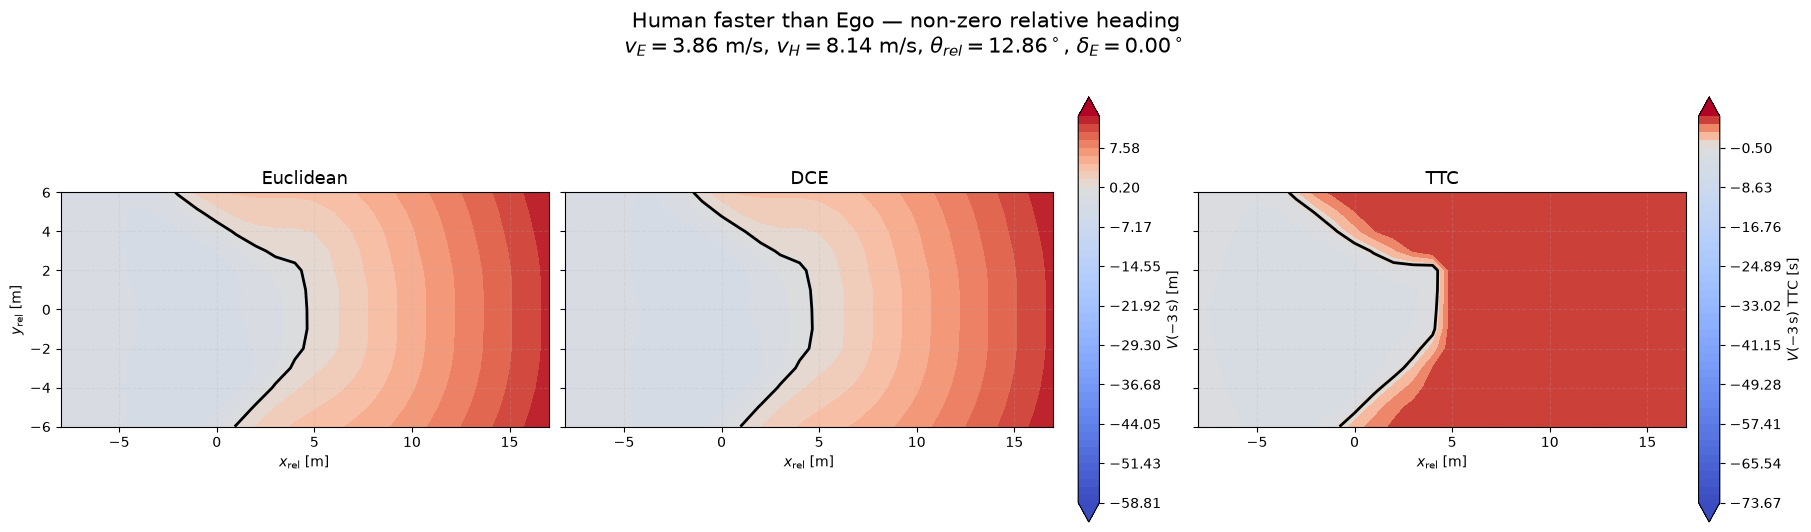

In [18]:
plot_xy_comparison(
    theta_index=i_theta_10,
    vH_index=i_vH_fast,
    vE_index=i_vE_slow,
    condition_name=(
        "Human faster than Ego — non-zero relative heading"
    ),
)


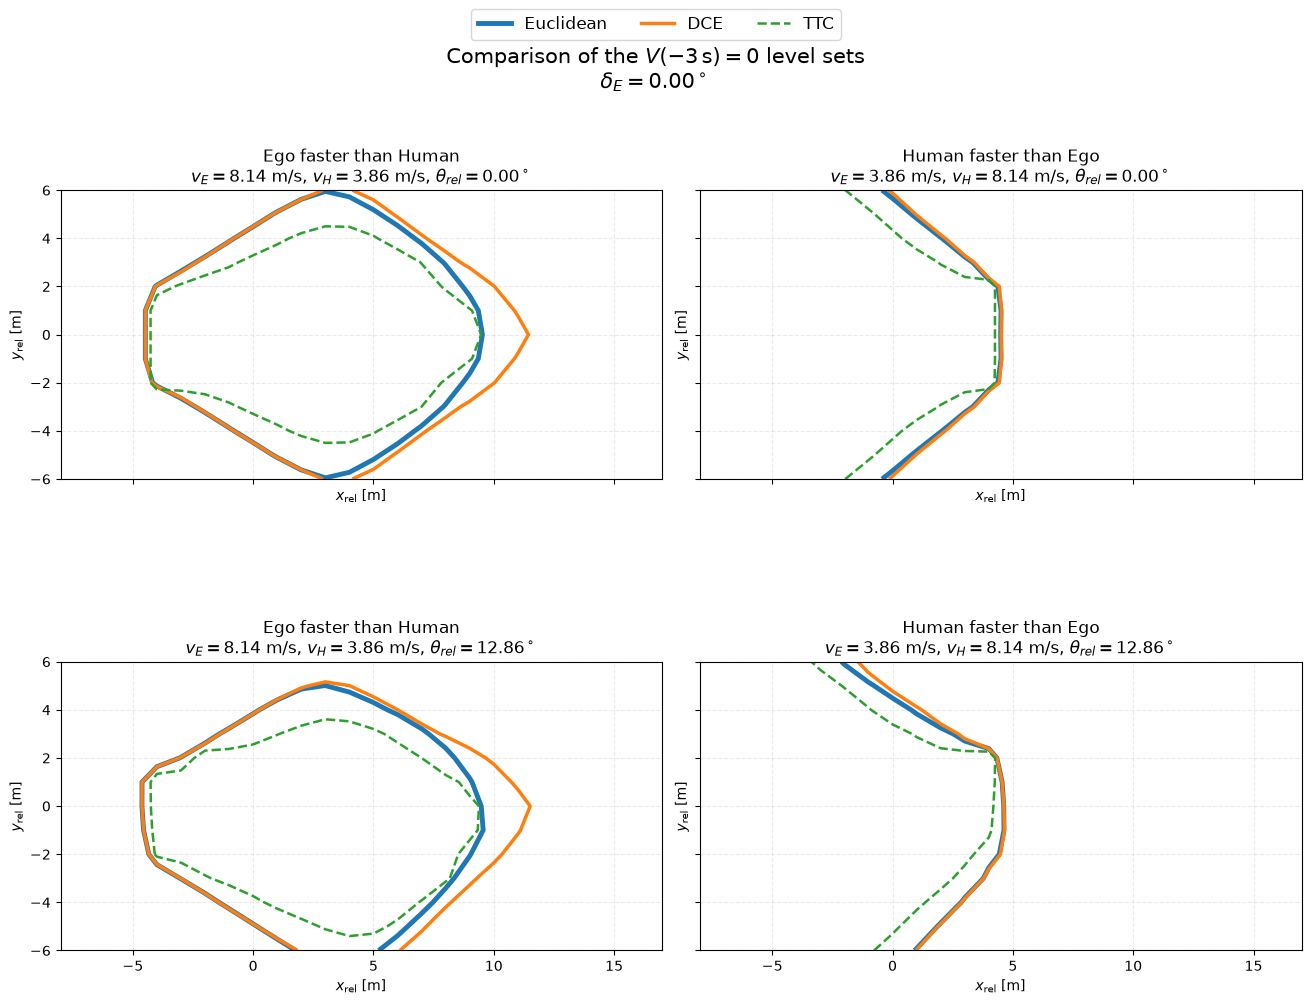

In [19]:
# ============================================================
# Zero-level comparison
# ============================================================

X, Y = np.meshgrid(
    x_rel,
    y_rel,
    indexing="ij",
)

cases = [
    {
        "theta_index": i_theta_0,
        "vH_index": i_vH_slow,
        "vE_index": i_vE_fast,
        "name": "Ego faster than Human",
    },
    {
        "theta_index": i_theta_0,
        "vH_index": i_vH_fast,
        "vE_index": i_vE_slow,
        "name": "Human faster than Ego",
    },
    {
        "theta_index": i_theta_10,
        "vH_index": i_vH_slow,
        "vE_index": i_vE_fast,
        "name": "Ego faster than Human",
    },
    {
        "theta_index": i_theta_10,
        "vH_index": i_vH_fast,
        "vE_index": i_vE_slow,
        "name": "Human faster than Ego",
    },
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 10),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

axes = axes.ravel()

for ax, case in zip(
    axes,
    cases,
):
    theta_index = case["theta_index"]
    vH_index = case["vH_index"]
    vE_index = case["vE_index"]

    V_e = get_xy_slice(
        V_euclidean,
        theta_index=theta_index,
        vH_index=vH_index,
        delta_index=i_delta_0,
        vE_index=vE_index,
    )

    V_d = get_xy_slice(
        V_dce,
        theta_index=theta_index,
        vH_index=vH_index,
        delta_index=i_delta_0,
        vE_index=vE_index,
    )

    V_t = get_xy_slice(
        V_ttc,
        theta_index=theta_index,
        vH_index=vH_index,
        delta_index=i_delta_0,
        vE_index=vE_index,
    )

    # Euclidean: thicker line underneath
    ax.contour(
        X,
        Y,
        V_e,
        levels=[0.0],
        colors="tab:blue",
        linewidths=3.5,
        linestyles="-",
    )

    # DCE
    ax.contour(
        X,
        Y,
        V_d,
        levels=[0.0],
        colors="tab:orange",
        linewidths=2.5,
        linestyles="-",
    )

    # TTC: dashed, so overlapping contours remain visible
    ax.contour(
        X,
        Y,
        V_t,
        levels=[0.0],
        colors="tab:green",
        linewidths=1.8,
        linestyles="--",
    )

    theta_deg = np.rad2deg(
        theta_rel[theta_index]
    )

    ax.set_title(
        (
            f"{case['name']}\n"
            rf"$v_E={v_E[vE_index]:.2f}$ m/s, "
            rf"$v_H={v_H[vH_index]:.2f}$ m/s, "
            rf"$\theta_{{rel}}={theta_deg:.2f}^\circ$"
        ),
        fontsize=12,
    )

    ax.set_xlabel(
        r"$x_{\mathrm{rel}}$ [m]"
    )

    ax.set_ylabel(
        r"$y_{\mathrm{rel}}$ [m]"
    )

    ax.set_xlim(
        x_rel.min(),
        x_rel.max(),
    )

    ax.set_ylim(
        y_rel.min(),
        y_rel.max(),
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.grid(
        alpha=0.25,
        linestyle="--",
    )


legend_handles = [
    Line2D(
        [0],
        [0],
        color="tab:blue",
        linewidth=3.5,
        label="Euclidean",
    ),
    Line2D(
        [0],
        [0],
        color="tab:orange",
        linewidth=2.5,
        label="DCE",
    ),
    Line2D(
        [0],
        [0],
        color="tab:green",
        linewidth=1.8,
        linestyle="--",
        label="TTC",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.04),
    fontsize=12,
)

fig.suptitle(
    (
        r"Comparison of the $V(-3\,\mathrm{s})=0$ level sets"
        "\n"
        rf"$\delta_E="
        f"{np.rad2deg(delta_0_value):.2f}"
        r"^\circ$"
    ),
    fontsize=15,
)

plt.show()
